# 02 — Exploratory Data Analysis

Univariate and bivariate exploration of the cleaned dataset, before any statistical testing or modeling. Working from `data/processed/diabetic_data_clean.csv` (cleaning decisions documented in `01_data_audit.ipynb` / `src/preprocessing.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/diabetic_data_clean.csv')
df.shape

(100114, 48)

## Target

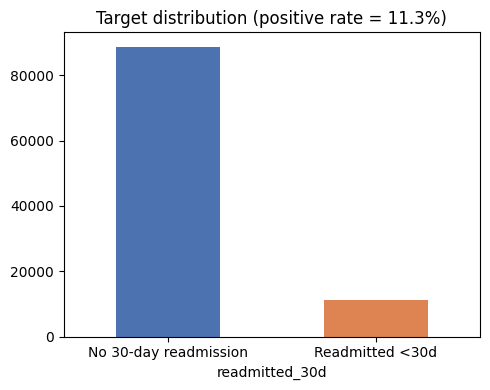

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
df['readmitted_30d'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No 30-day readmission', 'Readmitted <30d'], rotation=0)
ax.set_title(f"Target distribution (positive rate = {df['readmitted_30d'].mean():.1%})")
plt.tight_layout()
plt.show()

## Demographics

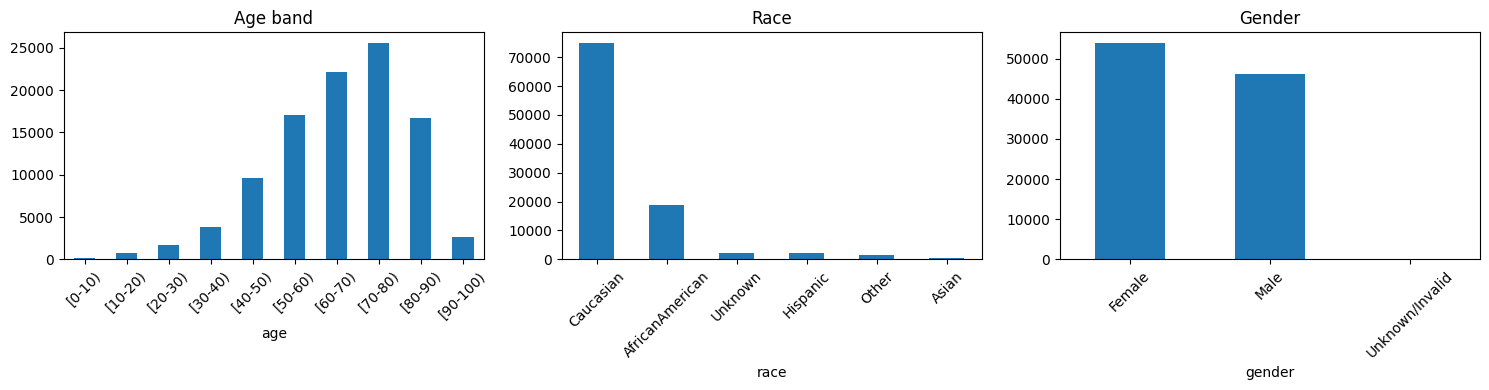

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['age'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Age band')
df['race'].value_counts().plot(kind='bar', ax=axes[1], title='Race')
df['gender'].value_counts().plot(kind='bar', ax=axes[2], title='Gender')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Readmission rate by key numeric features (binned)

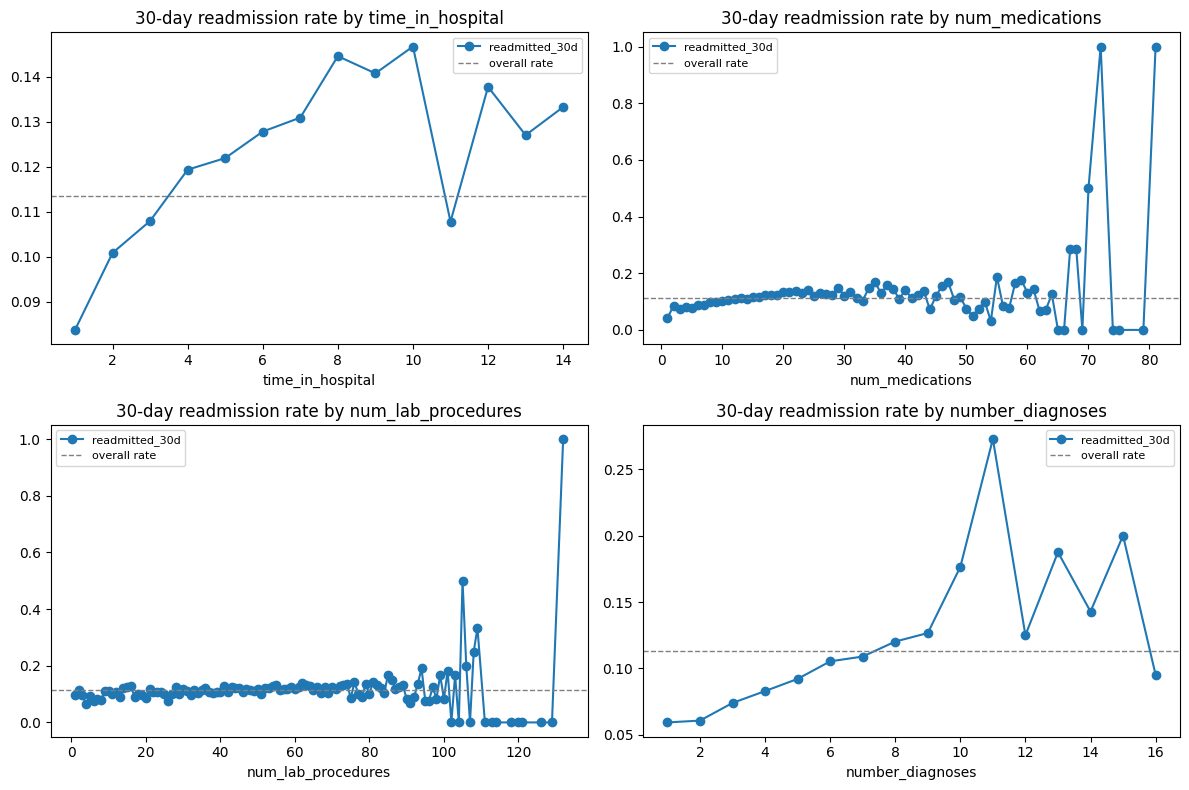

In [4]:
numeric_cols = ['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_diagnoses']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, numeric_cols):
    rate_by_bin = df.groupby(col)['readmitted_30d'].mean()
    rate_by_bin.plot(ax=ax, marker='o')
    ax.set_title(f'30-day readmission rate by {col}')
    ax.axhline(df['readmitted_30d'].mean(), color='gray', linestyle='--', linewidth=1, label='overall rate')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Prior utilization — the standout signal

This is the relationship the rest of the project leans on heavily (confirmed statistically in `03_statistical_analysis.ipynb`, confirmed as the top SHAP driver in `07_shap_analysis.ipynb`).

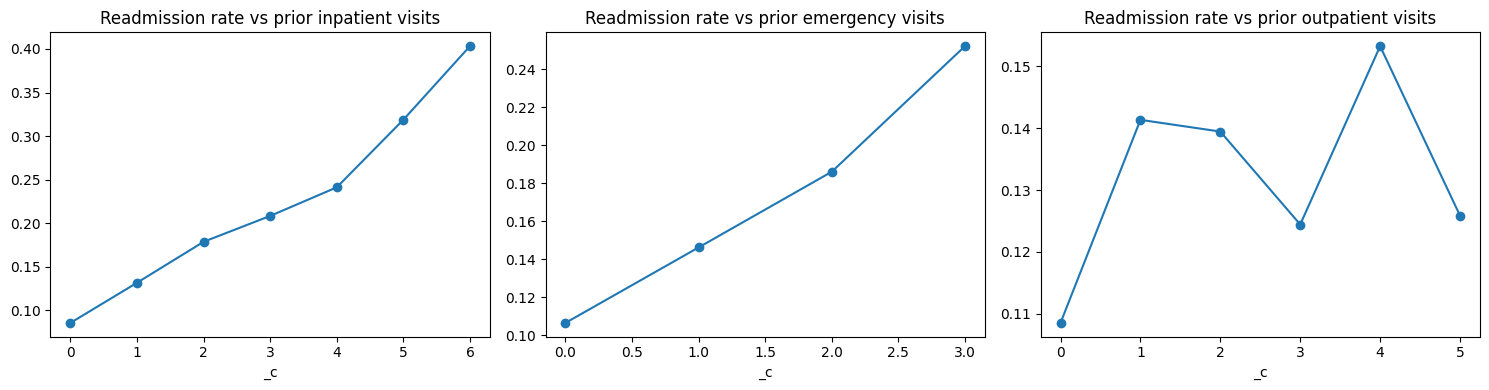

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['number_inpatient', 'number_emergency', 'number_outpatient']):
    capped = df[col].clip(upper=df[col].quantile(0.99))
    rate = df.assign(_c=capped).groupby('_c')['readmitted_30d'].mean()
    rate.plot(ax=ax, marker='o')
    ax.set_title(f'Readmission rate vs prior {col.replace("number_", "")} visits')
plt.tight_layout()
plt.show()

In [6]:
print('Readmission rate, no prior inpatient visits:', round(df.loc[df['number_inpatient']==0, 'readmitted_30d'].mean(), 3))
print('Readmission rate, 1+ prior inpatient visits: ', round(df.loc[df['number_inpatient']>0, 'readmitted_30d'].mean(), 3))
print('Readmission rate, 3+ prior inpatient visits: ', round(df.loc[df['number_inpatient']>=3, 'readmitted_30d'].mean(), 3))

Readmission rate, no prior inpatient visits: 0.086
Readmission rate, 1+ prior inpatient visits:  0.169
Readmission rate, 3+ prior inpatient visits:  0.262


## Categorical drivers

In [7]:
for col in ['A1Cresult', 'max_glu_serum', 'diabetesMed', 'change']:
    print(f'--- {col} ---')
    print(df.groupby(col)['readmitted_30d'].agg(['mean', 'count']).round(3))
    print()

--- A1Cresult ---
             mean  count
A1Cresult               
>7          0.101   3784
>8          0.099   8151
Norm        0.098   4941
Not tested  0.116  83238

--- max_glu_serum ---
                mean  count
max_glu_serum              
>200           0.128   1440
>300           0.149   1211
Norm           0.115   2573
Not tested     0.113  94890

--- diabetesMed ---
              mean  count
diabetesMed              
No           0.098  22842
Yes          0.118  77272

--- change ---
         mean  count
change              
Ch      0.120  46443
No      0.108  53671



## Takeaways for feature engineering / modeling

- Readmission rate rises sharply and close to monotonically with prior inpatient/emergency/outpatient visits — motivates the `prior_utilization` / `high_utilizer` features in `04_feature_engineering.ipynb`.
- `number_diagnoses` and `time_in_hospital` show a mild positive relationship with readmission — feeds `comorbidity_burden` / `hospitalization_intensity`.
- Differences across `A1Cresult` / `max_glu_serum` / `diabetesMed` look small by eye here; formal hypothesis tests in the next notebook settle whether they're statistically meaningful at this sample size.
- Demographic distributions are heavily skewed toward Caucasian and 50-90 age bands — flagged here as a fairness-audit concern for later (`10_fairness_analysis.ipynb`), since low-n subgroups (Asian, Hispanic, [0-10)) will have noisy subgroup metrics.